# Elections Cleanroom Dataset Analysis

Run this notebook from the repo root. It inspects cleanroom outputs under `data/processed/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Robust root detection: use repo root if present, else parent of notebooks/
cwd = Path.cwd().resolve()
if (cwd / 'data' / 'processed').exists():
    ROOT = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError('Could not find data/processed. Run scripts/build_all.py from repo root.')

DATA = ROOT / 'data' / 'processed'

country = pd.read_parquet(DATA / 'country.parquet')
party = pd.read_parquet(DATA / 'party.parquet')
party_crosswalk = pd.read_parquet(DATA / 'party_crosswalk.parquet')
party_ideo = pd.read_parquet(DATA / 'party_ideology_obs.parquet')
sources = pd.read_parquet(DATA / 'election_event_sources.parquet')
events = pd.read_parquet(DATA / 'election_event.parquet')
horizon = pd.read_parquet(DATA / 'election_event_horizon_efw.parquet')

len(country), len(party), len(party_crosswalk), len(party_ideo), len(sources), len(events), len(horizon)


(239, 7246, 5684, 9843, 8613, 8607, 77463)

## 1) Quick structure checks

In [2]:
tables = {
    'country': country,
    'party': party,
    'party_crosswalk': party_crosswalk,
    'party_ideology_obs': party_ideo,
    'election_event_sources': sources,
    'election_event': events,
    'election_event_horizon_efw': horizon,
}

summary = []
for name, df in tables.items():
    summary.append({
        'table': name,
        'rows': len(df),
        'cols': len(df.columns),
    })
pd.DataFrame(summary)

,table,rows,cols
0,country,239,17
1,party,7246,12
2,party_crosswalk,5684,6
3,party_ideology_obs,9843,7
4,election_event_sources,8613,63
5,election_event,8607,83
6,election_event_horizon_efw,77463,23


## 2) Time coverage and ISO3 coverage

In [3]:
events['election_year'].min(), events['election_year'].max(), events['iso3'].nunique()

(1788, 2024, 200)

In [4]:
events_2000 = events[events['election_year'] >= 2000]
pd.Series({
    'rows_2000_plus': len(events_2000),
    'iso3_missing_pct': events_2000['iso3'].isna().mean(),
    'share_1_missing_pct': events_2000['share_1'].isna().mean(),
    'party_1_id_missing_pct': events_2000['party_1_id'].isna().mean(),
    'margin_market_missing_pct': events_2000['margin_market'].isna().mean(),
})

rows_2000_plus               2552.000000
iso3_missing_pct                0.084639
share_1_missing_pct             0.032132
party_1_id_missing_pct          0.748433
margin_market_missing_pct       0.893809
dtype: float64

## 3) Clean and competitive samples

In [5]:
events[['clean_flag', 'competitive_flag', 'competitive_sample_strict', 'competitive_sample_conservative']].mean(numeric_only=True)

clean_flag                         0.963634
competitive_flag                   0.323922
competitive_sample_strict          0.314511
competitive_sample_conservative    0.314511
dtype: float64

## 4) Ideology source coverage

In [6]:
events['ideo_source'].value_counts(dropna=False)

ideo_source
None       7056
mixed      1043
vparty      412
parlgov      89
ches          5
elff          2
Name: count, dtype: int64

## 5) Margin distributions

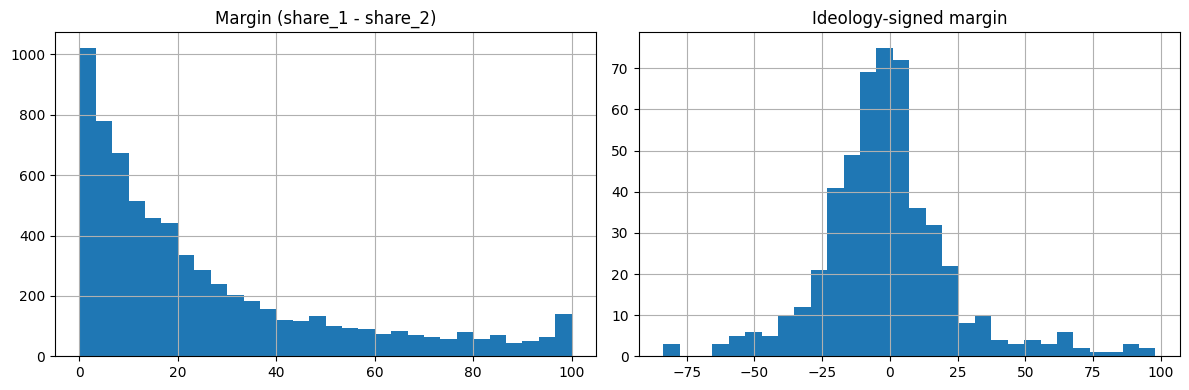

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
events['margin'].dropna().hist(ax=ax[0], bins=30)
ax[0].set_title('Margin (share_1 - share_2)')
events['margin_market'].dropna().hist(ax=ax[1], bins=30)
ax[1].set_title('Ideology-signed margin')
plt.tight_layout()

## 6) EFW alignment coverage

In [8]:
events['efw_match_status'].value_counts(dropna=False)

efw_match_status
no_efw_country    5921
matched           2107
no_iso3            579
Name: count, dtype: int64

In [9]:
horizon.groupby('horizon')['efw_horizon_match_status'].value_counts(dropna=False).unstack(fill_value=0)

efw_horizon_match_status,matched,missing_baseline,missing_outcome
horizon,,,
0,1814,333,6460
1,1754,484,6369
2,1698,513,6396
3,1627,570,6410
4,1828,367,6412
5,1509,655,6443
6,1433,770,6404
7,1368,813,6426
8,1288,869,6450


## 7) Cross-source overlap (NED vs CLEA)

In [10]:
sources['source'].value_counts()

source
ned_parl    4900
clea_lc     2304
ned_pres    1409
Name: count, dtype: int64

In [11]:
overlap = sources.groupby('election_id')['source'].nunique()
overlap.value_counts().sort_index()

source
1    8613
Name: count, dtype: int64

## 8) Top missing ISO3 in 2000+

In [12]:
events_2000[events_2000['iso3'].isna()][['country_name_raw']].value_counts().head(20)

country_name_raw  
Serbia                26
Montenegro            21
Kosovo                18
USA                   18
Timor-Leste           17
Bahamas               10
Samoa                  9
Ivory Coast            8
Congo (DRC)            8
UK                     7
Somaliland             7
Curaçao                6
Hong Kong              6
St. Lucia              5
Aland Islands          5
Macau                  5
Côte d'Ivoire          4
Russian Federation     4
Curacao                4
Sint Maarten           4
Name: count, dtype: int64